In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
files = {
	# ===== DeBERTa 512 =====
	"deberta_42":     "deberta_processed/deberta_seed_42_processed/submission_seed42.csv",
	"deberta_1337":   "deberta_processed/deberta_seed_1337_processed/submission_seed_daberta_processed1337.csv",
	"deberta_2024":   "deberta_processed/deberta_seed_2024_processed/submission_seed_daberta_processed2024.csv",
	"deberta_noseed": "deberta_processed/submission_deberta_processed_noseed_MAXLEN_512.csv",

	# ===== DeBERTa 256 =====
	"deberta256_noseed": "deberta_MAXLEN256/submission_deberta_processed_noseed_MAXLEN_256.csv",
    "deberta256_42" :  "deberta_MAXLEN256/deberta_seed42_MAXLEN256\submission_roberta_processed_seed42_MAXLEN256.csv",
    "deberta256_1337" : "deberta_MAXLEN256/deberta_seed1337_MAXLEN256/submission_roberta_processed_seed1337_MAXLEN256.csv",
    "deberta256_2024" : "deberta_MAXLEN256/deberta_seed2024_MAXLEN256/submission_roberta_processed_seed2024_MAXLEN256.csv",

	# ===== RoBERTa 512 =====
	"roberta_42":     "roberta_processed/roberta_processed_seed_42/submission_seed_roberta_processed42.csv",
	"roberta_1337":   "roberta_processed/roberta_processed_seed_1337/submission_seed_roberta_processed1337.csv",
	"roberta_2024":   "roberta_processed/roberta_processed_seed_2024/submission_seed_roberta_processed2024.csv",
	"roberta_noseed": "roberta_processed/submission_roberta_processed_noseed_MAXLEN_512.csv",

	# ===== RoBERTa 256 =====
	"roberta256_42":   "roberta_MAXLEN256/roberta_seed42_MAXLEN256/submission_roberta_processed_seed42_MAXLEN256.csv",
	"roberta256_1337": "roberta_MAXLEN256/roberta_seed1337_MAXLEN256/submission_roberta_processed_seed1337_MAXLEN256.csv",
	"roberta256_2024": "roberta_MAXLEN256/roberta_seed2024_MAXLEN256/submission_roberta_processed_seed2024_MAXLEN256.csv",
    "roberta_256_noseed" : "roberta_MAXLEN256/submission_roberta_processed_noseed_MAXLEN_256.csv"
}

In [3]:
# Load predictions
preds = {}

for name, path in files.items():
	df = pd.read_csv(path)
	# assume column name is 'label' or similar
	preds[name] = df.iloc[:, -1].values  # ultima colonna = label

# Convert to DataFrame
preds_df = pd.DataFrame(preds)
print(preds_df.shape)


(20000, 16)


In [14]:
# Hard cases = rows with disagreement across models
hard_mask = preds_df.nunique(axis=1) > 1
hard_df = preds_df[hard_mask]

print(f"Hard cases: {hard_df.shape[0]} / {preds_df.shape[0]}")


Hard cases: 6839 / 20000


In [15]:
arch_models = {
	"DeBERTa-512": "deberta_noseed",
	"DeBERTa-256": "deberta256_noseed",
	"RoBERTa-512": "roberta_noseed",
	"RoBERTa-256": "roberta_256_noseed"
}

arch_df = hard_df[[v for v in arch_models.values()]]
arch_df.columns = list(arch_models.keys())


In [16]:
models = arch_df.columns
overlap = pd.DataFrame(index=models, columns=models, dtype=float)

for m1 in models:
	for m2 in models:
		overlap.loc[m1, m2] = np.mean(arch_df[m1] == arch_df[m2])

overlap = overlap.astype(float)
overlap


,DeBERTa-512,DeBERTa-256,RoBERTa-512,RoBERTa-256
DeBERTa-512,1.000000,0.628601,0.567919,0.555637
DeBERTa-256,0.628601,1.000000,0.557684,0.555637
RoBERTa-512,0.567919,0.557684,1.000000,0.646732
RoBERTa-256,0.555637,0.555637,0.646732,1.000000


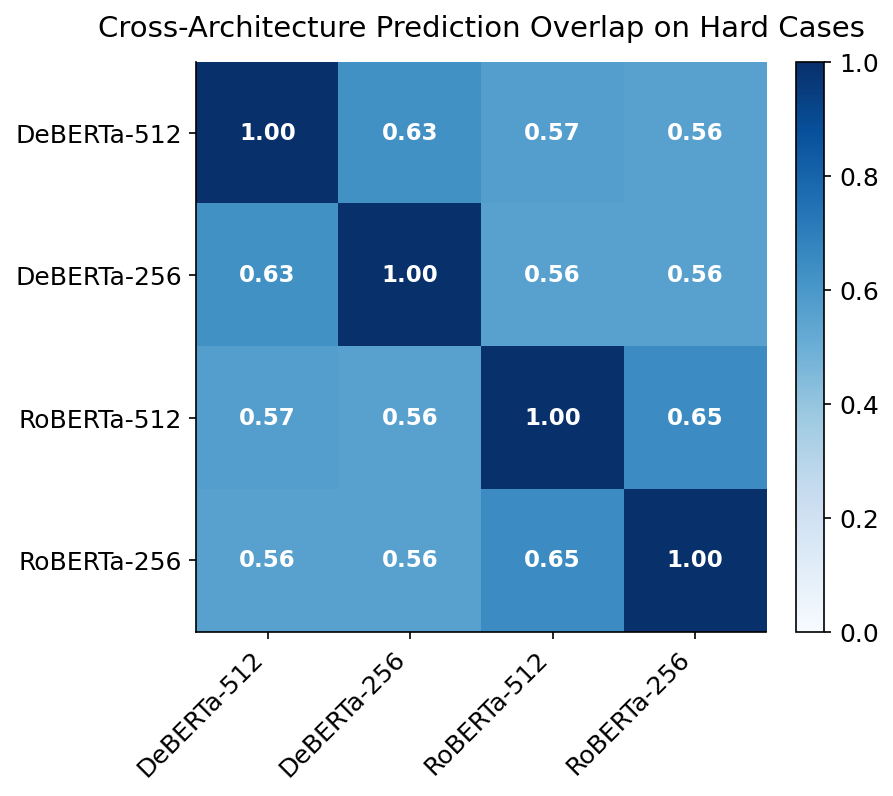

In [31]:
import matplotlib.pyplot as plt
import numpy as np

models = overlap.index.tolist()
data   = overlap.values

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(data, cmap="Blues", vmin=0, vmax=1)

for i in range(len(models)):
	for j in range(len(models)):
		ax.text(
			j, i, f"{data[i, j]:.2f}",
			ha="center", va="center",
			color="white",
			fontsize=11,
			fontweight="bold"
		)

ax.set_xticks(range(len(models)))
ax.set_yticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha="right")
ax.set_yticklabels(models)

ax.set_title("Cross-Architecture Prediction Overlap on Hard Cases", pad=12)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

